<a href="https://colab.research.google.com/github/hamza16071/Linear_Regression/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
# Dataset online import

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00477/Real%20estate%20valuation%20data%20set.xlsx"

df = pd.read_excel(url)

df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [ ]:
# Dataset Summary

df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [ ]:
# Mising Value Check

df.isnull().sum()

,0
No,0
X1 transaction date,0
X2 house age,0
X3 distance to the nearest MRT station,0
X4 number of convenience stores,0
X5 latitude,0
X6 longitude,0
Y house price of unit area,0


In [ ]:
# Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [ ]:
# Check Column

df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [ ]:
# X and Y Define

X = df[["X2 house age"]]

y = df["Y house price of unit area"]

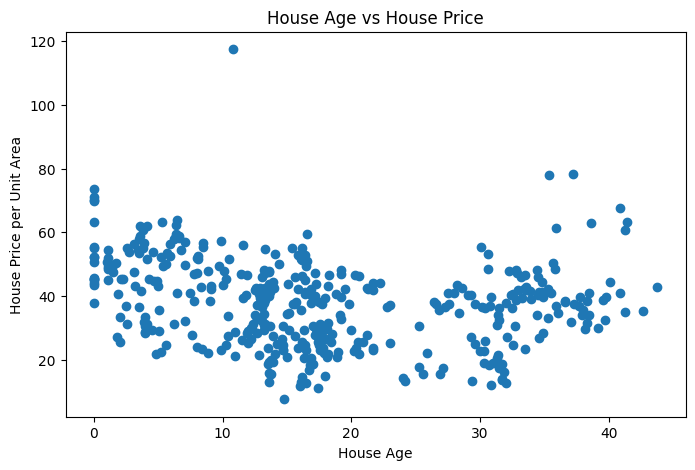

In [ ]:
# Relationship Visualize

plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel("House Age")
plt.ylabel("House Price per Unit Area")
plt.title("House Age vs House Price")

plt.show()

In [ ]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
# Defin or Check Shapes

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (331, 1)
X_test: (83, 1)
y_train: (331,)
y_test: (83,)


In [ ]:
# Create Model

model = LinearRegression()

In [ ]:
# Model Train

model.fit(X_train, y_train) # .fit (Training data se model ke parameters learn karo.)

LinearRegression()

In [ ]:
# Learned parameters

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: -0.25978378264384744
Intercept: 42.88289629775735


In [ ]:
# Test on Prediction Data

y_pred = model.predict(X_test)

In [ ]:
# Actual vs Predicted

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,45.1,42.597134
1,42.3,39.453750
2,52.2,42.882896
3,37.3,39.583642
4,22.8,37.635264
5,36.3,34.439923
6,53.0,38.752334
7,51.4,38.674399
8,16.1,34.595794
9,59.0,41.168323


In [ ]:
# Calculate MAE

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 10.621234812005051


In [ ]:
# Calculate MSE

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 165.2051150828318


In [ ]:
# Calculate RMSE

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 12.853214192676935


In [ ]:
# R² model ke explained variance relative

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.015227904910820378


In [ ]:
# Complete evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 10.621234812005051
MSE : 165.2051150828318
RMSE: 12.853214192676935
R²  : 0.015227904910820378


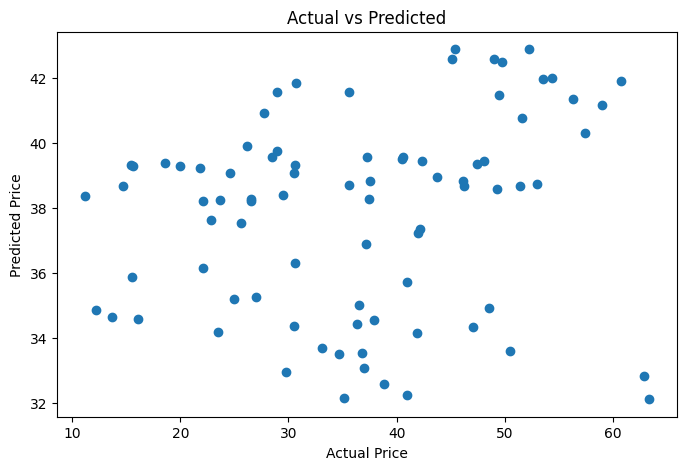

In [ ]:
# Actual vs Predicted graph

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

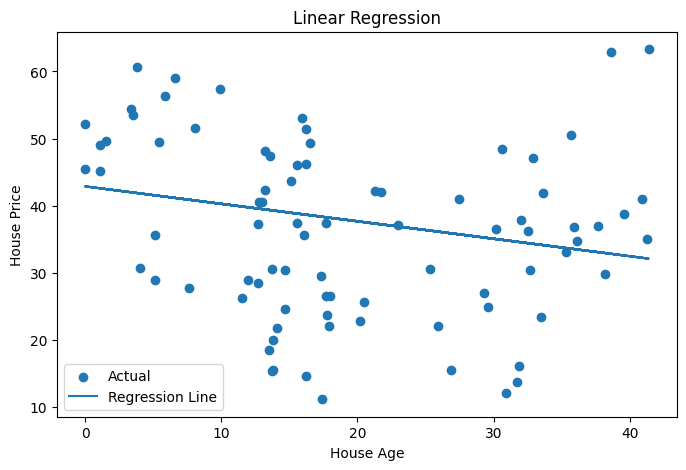

In [ ]:
# Regression line visualize

plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, label="Actual")

plt.plot(
    X_test,
    y_pred,
    label="Regression Line"
)

plt.xlabel("House Age")
plt.ylabel("House Price")
plt.title("Linear Regression")

plt.legend()
plt.show()

In [ ]:
X = df[
    [
        "X2 house age",
        "X3 distance to the nearest MRT station",
        "X4 number of convenience stores",
        "X5 latitude",
        "X6 longitude"
    ]
]

y = df["Y house price of unit area"]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)